# ============================================================
# SPAM DETECTION SYSTEM - FULL TRAINING NOTEBOOK
# ============================================================
# يحتوي على جميع التعديلات:
# 1. Fix Data Leakage (Split BEFORE fit)
# 2. Overfitting protection for Decision Tree
# 3. Handled Imbalance with class_weight
# 4. Cross-validation for stability
# 5. Proper preprocessing
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import re
import string
import scipy.sparse as sp
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, classification_report, confusion_matrix,
                            roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Download NLTK data
print("📥 Downloading NLTK data...")
for package in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(package, quiet=True)
    except:
        pass

📥 Downloading NLTK data...


## LOAD DATA

 Try different encodings

In [2]:
df = None
encodings = ['latin-1', 'utf-8', 'cp1252', 'iso-8859-1']

for enc in encodings:
    try:
        df = pd.read_csv("spam.csv", encoding=enc)
        print(f"✅ Loaded with encoding: {enc}")
        break
    except:
        try:
            df = pd.read_csv("data/spam.csv", encoding=enc)
            print(f"✅ Loaded with encoding: {enc}")
            break
        except:
            continue

if df is None:
    print("❌ Could not load spam.csv!")
    print("   Please make sure the file exists in the current directory or 'data/' folder")
    exit()

✅ Loaded with encoding: latin-1


Clean data

In [3]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df = df[df['label'].isin(['ham', 'spam'])]
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"\n Dataset Statistics:")
print(f"   Total messages: {len(df):,}")
print(f"   Ham (legitimate): {(df['label']==0).sum():,} ({((df['label']==0).sum()/len(df))*100:.1f}%)")
print(f"   Spam: {(df['label']==1).sum():,} ({((df['label']==1).sum()/len(df))*100:.1f}%)")


 Dataset Statistics:
   Total messages: 5,572
   Ham (legitimate): 4,825 (86.6%)
   Spam: 747 (13.4%)


In [4]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## PREPROCESSING

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Clean and preprocess text message"""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r'\d+', '', text)       # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]  # Remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]   # Lemmatization
    return " ".join(words)

Spam keywords feature

In [6]:

SPAM_KEYWORDS = [
    'free', 'win', 'winner', 'cash', 'prize', 'claim',
    'urgent', 'congratulations', 'click', 'offer', 'deal',
    'money', 'call now', 'limited time', 'subscribe',
    'txt', 'mobile', 'ringtone', 'reply stop'
]

def has_spam_keyword(text):
    text = text.lower()
    return int(any(word in text for word in SPAM_KEYWORDS))

df['has_spam_word'] = df['message'].apply(has_spam_keyword)


Apply preprocessing

In [7]:

df['cleaned'] = df['message'].apply(preprocess)
df['has_spam_word'] = df['message'].apply(has_spam_keyword)
print(" Preprocessing complete")


 Preprocessing complete


## TRAIN-TEST SPLIT

In [8]:
print("\n SPLITTING DATA")
print("-"*50)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned'], df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

train_idx = X_train_text.index
test_idx = X_test_text.index

print(f" Training set: {len(X_train_text)} samples")
print(f" Test set: {len(X_test_text)} samples")


 SPLITTING DATA
--------------------------------------------------
 Training set: 4457 samples
 Test set: 1115 samples


## FEATURE EXTRACTION (TF-IDF)



In [9]:

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

# Fit on training data only (NO DATA LEAKAGE!)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Add spam keyword feature

X_train_extra = df.loc[train_idx, ['has_spam_word']].values
X_test_extra = df.loc[test_idx, ['has_spam_word']].values

# Stack features

X_train = sp.hstack((X_train_tfidf, X_train_extra))
X_test = sp.hstack((X_test_tfidf, X_test_extra))

print(f" TF-IDF features: {X_train_tfidf.shape[1]}")
print(f" Total features: {X_train.shape[1]}")

train_idx = X_train_text.index
test_idx = X_test_text.index

 TF-IDF features: 5000
 Total features: 5001


##  TRAIN ALL MODELS



In [10]:
results = []
models_dict = {}

## **model 1 (Naive Bayes model)**

In [11]:
nb_model = MultinomialNB(alpha=0.5)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
nb_model.fit(X_train, y_train, sample_weight=sample_weights)
models_dict['Naive Bayes'] = nb_model

# Evaluate
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]

nb_results = {
    'Algorithm': 'Naive Bayes',
    'Student': '[Student 1 Name]',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
}
results.append(nb_results)
print(f"    Accuracy: {nb_results['Accuracy']:.4f}")
print(f"    Precision: {nb_results['Precision']:.4f}")
print(f"    Recall: {nb_results['Recall']:.4f}")
print(f"    F1-Score: {nb_results['F1-Score']:.4f}")
print(f"    AUC: {nb_results['AUC']:.4f}")

    Accuracy: 0.9668
    Precision: 0.8373
    Recall: 0.9329
    F1-Score: 0.8825
    AUC: 0.9841


## **model 2 (Logistic Regression)**

In [12]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
models_dict['Logistic Regression'] = lr_model

y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]

lr_results = {
    'Algorithm': 'Logistic Regression',
    'Student': '[Student 2 Name]',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
}
results.append(lr_results)
print(f"    Accuracy: {lr_results['Accuracy']:.4f}")
print(f"    Precision: {lr_results['Precision']:.4f}")
print(f"    Recall: {lr_results['Recall']:.4f}")
print(f"    F1-Score: {lr_results['F1-Score']:.4f}")


    Accuracy: 0.9543
    Precision: 0.7753
    Recall: 0.9262
    F1-Score: 0.8440



##  model 3 Support Vector Machine 


In [13]:
svm_model = SVC(kernel='linear', C=1, class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
models_dict['SVM'] = svm_model

y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

svm_results = {
    'Algorithm': 'SVM',
    'Student': '[Student 3 Name]',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
}
results.append(svm_results)
print(f"    Accuracy: {svm_results['Accuracy']:.4f}")
print(f"    Precision: {svm_results['Precision']:.4f}")
print(f"    Recall: {svm_results['Recall']:.4f}")
print(f"    F1-Score: {svm_results['F1-Score']:.4f}")

    Accuracy: 0.9821
    Precision: 0.9510
    Recall: 0.9128
    F1-Score: 0.9315


## **model 4 (Random Forest)**

In [14]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

In [15]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
models_dict['Random Forest'] = rf_model

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    'Algorithm': 'Random Forest',
    'Student': '[Student 5 Name]',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
}
results.append(rf_results)
print(f"    Accuracy: {rf_results['Accuracy']:.4f}")
print(f"    Precision: {rf_results['Precision']:.4f}")
print(f"    Recall: {rf_results['Recall']:.4f}")
print(f"    F1-Score: {rf_results['F1-Score']:.4f}")

    Accuracy: 0.9758
    Precision: 1.0000
    Recall: 0.8188
    F1-Score: 0.9004


## **model 5 (Decision Tree)**

In [16]:
dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)
models_dict['Decision Tree'] = dt_model

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

dt_results = {
    'Algorithm': 'Decision Tree',
    'Student': '[Student 4 Name]',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
}
results.append(dt_results)
print(f"    Accuracy: {dt_results['Accuracy']:.4f}")
print(f"    Precision: {dt_results['Precision']:.4f}")
print(f"    Recall: {dt_results['Recall']:.4f}")
print(f"    F1-Score: {dt_results['F1-Score']:.4f}")


    Accuracy: 0.9327
    Precision: 0.6968
    Recall: 0.8792
    F1-Score: 0.7774


## COMPARISON AND VISUALIZATION

In [17]:

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n COMPARISON TABLE:")
print("="*100)
print(f"{'Algorithm':<20}  {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10}")
print("="*100)
for _, row in comparison_df.iterrows():
    print(f"{row['Algorithm']:<20}  {row['Accuracy']:.4f}     {row['Precision']:.4f}     {row['Recall']:.4f}     {row['F1-Score']:.4f}     {row['AUC']:.4f}")
print("="*100)

# Find best models
best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_auc = comparison_df.loc[comparison_df['AUC'].idxmax()]

print("\n BEST MODELS:")
print(f"   Best Accuracy: {best_accuracy['Algorithm']} ({best_accuracy['Accuracy']:.4f}) ")
print(f"   Best F1-Score: {best_f1['Algorithm']} ({best_f1['F1-Score']:.4f}) ")
print(f"   Best AUC: {best_auc['Algorithm']} ({best_auc['AUC']:.4f}) ")

# Save comparison results
comparison_df.to_csv('results/comparison_results.csv', index=False)
print("\n Comparison results saved to: results/comparison_results.csv")



 COMPARISON TABLE:
Algorithm             Accuracy   Precision  Recall     F1-Score   AUC       
Naive Bayes           0.9668     0.8373     0.9329     0.8825     0.9841
Logistic Regression   0.9543     0.7753     0.9262     0.8440     0.9817
SVM                   0.9821     0.9510     0.9128     0.9315     0.9865
Random Forest         0.9758     1.0000     0.8188     0.9004     0.9873
Decision Tree         0.9327     0.6968     0.8792     0.7774     0.9009

 BEST MODELS:
   Best Accuracy: SVM (0.9821) 
   Best F1-Score: SVM (0.9315) 
   Best AUC: Random Forest (0.9873) 

 Comparison results saved to: results/comparison_results.csv


## CLASSIFICATION REPORTS

In [ ]:
for name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print('='*60)
    
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n Confusion Matrix:")
    print(f"              Predicted")
    print(f"   Actual Ham  : {cm[0,0]:5d}   {cm[0,1]:5d}")
    print(f"          Spam : {cm[1,0]:5d}   {cm[1,1]:5d}")
    print()


 Naive Bayes
              precision    recall  f1-score   support

     Ham (0)       0.99      0.97      0.98       966
    Spam (1)       0.84      0.93      0.88       149

    accuracy                           0.97      1115
   macro avg       0.91      0.95      0.93      1115
weighted avg       0.97      0.97      0.97      1115


 Confusion Matrix:
              Predicted
   Actual Ham  :   939      27
          Spam :    10     139


 Logistic Regression
              precision    recall  f1-score   support

     Ham (0)       0.99      0.96      0.97       966
    Spam (1)       0.78      0.93      0.84       149

    accuracy                           0.95      1115
   macro avg       0.88      0.94      0.91      1115
weighted avg       0.96      0.95      0.96      1115


 Confusion Matrix:
              Predicted
   Actual Ham  :   926      40
          Spam :    11     138


 SVM
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99  

## VISUALIZATIONS



 GENERATING VISUALIZATIONS
--------------------------------------------------


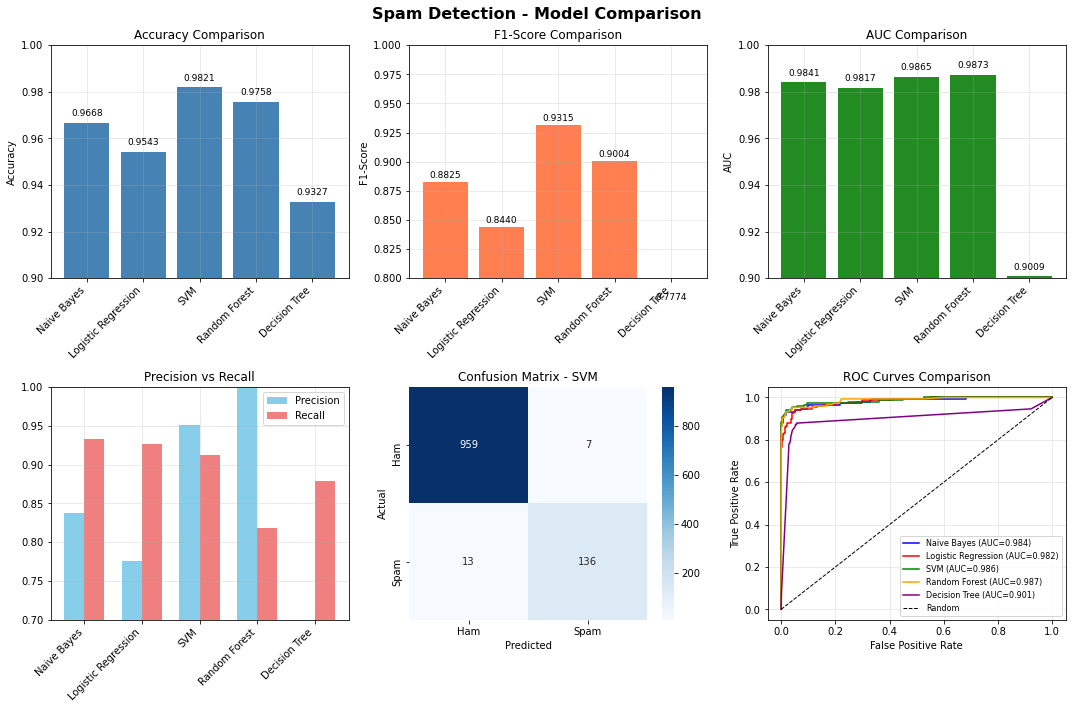

Visualizations saved to: results/model_comparison.png


In [19]:
print("\n GENERATING VISUALIZATIONS")
print("-"*50)

# Set style (using default instead of seaborn style)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 1. Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Spam Detection - Model Comparison', fontsize=16, fontweight='bold')

# Accuracy bar chart
ax = axes[0, 0]
bars = ax.bar(comparison_df['Algorithm'], comparison_df['Accuracy'], color='steelblue')
ax.set_title('Accuracy Comparison')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, comparison_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# F1-Score bar chart
ax = axes[0, 1]
bars = ax.bar(comparison_df['Algorithm'], comparison_df['F1-Score'], color='coral')
ax.set_title('F1-Score Comparison')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, comparison_df['F1-Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# AUC bar chart
ax = axes[0, 2]
bars = ax.bar(comparison_df['Algorithm'], comparison_df['AUC'], color='forestgreen')
ax.set_title('AUC Comparison')
ax.set_ylabel('AUC')
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, comparison_df['AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Precision vs Recall
ax = axes[1, 0]
x = np.arange(len(comparison_df['Algorithm']))
width = 0.35
ax.bar(x - width/2, comparison_df['Precision'], width, label='Precision', color='skyblue')
ax.bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='lightcoral')
ax.set_title('Precision vs Recall')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Algorithm'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.0)

# Confusion Matrix for best model
ax = axes[1, 1]
best_model_name = best_f1['Algorithm']
best_model = models_dict[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ROC Curves
ax = axes[1, 2]
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i, (name, model) in enumerate(models_dict.items()):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=1.5, 
                label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_title('ROC Curves Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved to: results/model_comparison.png")

## CROSS-VALIDATION RESULT

In [20]:

print("\n CROSS-VALIDATION RESULTS")
print("-"*50)

cv_results = []
for name, model in models_dict.items():
    try:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
        cv_results.append({
            'Algorithm': name,
            'CV Mean F1': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })
    except Exception as e:
        print(f" Could not run CV for {name}: {e}")

if cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("\n 5-Fold Cross-Validation Results:")
    print(cv_df.to_string(index=False))




 CROSS-VALIDATION RESULTS
--------------------------------------------------

 5-Fold Cross-Validation Results:
          Algorithm  CV Mean F1   CV Std
        Naive Bayes    0.922360 0.012596
Logistic Regression    0.809963 0.017963
                SVM    0.918452 0.007385
      Random Forest    0.914462 0.016666
      Decision Tree    0.765277 0.015694


## SAVE MODELS

In [21]:
print("\n SAVING MODELS")
print("-"*50)

os.makedirs('models', exist_ok=True)

for name, model in models_dict.items():
    filename = f"models/{name.lower().replace(' ', '_')}_model.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f" Saved: {filename}")

with open("models/vectorizer.pkl", 'wb') as f:
    pickle.dump(tfidf, f)
print(f" Saved: models/vectorizer.pkl")


 SAVING MODELS
--------------------------------------------------
 Saved: models/naive_bayes_model.pkl
 Saved: models/logistic_regression_model.pkl
 Saved: models/svm_model.pkl
 Saved: models/random_forest_model.pkl
 Saved: models/decision_tree_model.pkl
 Saved: models/vectorizer.pkl


## FINAL SUMMARY

In [22]:
print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)

print("\n FILES GENERATED:")
print("    models/ - All trained models")
print("    results/comparison_results.csv - Comparison table")
print("    results/model_comparison.png - Visualization")

print("\n FINAL RESULTS SUMMARY:")
print("-"*60)
for _, row in comparison_df.iterrows():
    print(f"\n {row['Algorithm']} ({row['Student']}):")
    print(f"   Accuracy:  {row['Accuracy']:.4f}")
    print(f"   Precision: {row['Precision']:.4f}")
    print(f"   Recall:    {row['Recall']:.4f}")
    print(f"   F1-Score:  {row['F1-Score']:.4f}")
    print(f"   AUC:       {row['AUC']:.4f}")

print("\n NEXT STEPS:")
print("   1. Run the GUI using: python main.py")
print("   2. Test the system with custom messages")
print("   3. Prepare documentation and video")

print("\n" + "="*80)
print(" SPAM DETECTION SYSTEM READY!")
print(" ALL 5 ALGORITHMS TRAINED SUCCESSFULLY!")
print("="*80)


 TRAINING COMPLETE!

 FILES GENERATED:
    models/ - All trained models
    results/comparison_results.csv - Comparison table
    results/model_comparison.png - Visualization

 FINAL RESULTS SUMMARY:
------------------------------------------------------------

 Naive Bayes ([Student 1 Name]):
   Accuracy:  0.9668
   Precision: 0.8373
   Recall:    0.9329
   F1-Score:  0.8825
   AUC:       0.9841

 Logistic Regression ([Student 2 Name]):
   Accuracy:  0.9543
   Precision: 0.7753
   Recall:    0.9262
   F1-Score:  0.8440
   AUC:       0.9817

 SVM ([Student 3 Name]):
   Accuracy:  0.9821
   Precision: 0.9510
   Recall:    0.9128
   F1-Score:  0.9315
   AUC:       0.9865

 Random Forest ([Student 5 Name]):
   Accuracy:  0.9758
   Precision: 1.0000
   Recall:    0.8188
   F1-Score:  0.9004
   AUC:       0.9873

 Decision Tree ([Student 4 Name]):
   Accuracy:  0.9327
   Precision: 0.6968
   Recall:    0.8792
   F1-Score:  0.7774
   AUC:       0.9009

 NEXT STEPS:
   1. Run the GUI using: 